In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.ticker as ticker


from simulation.make_dataset import make_dataset
from simulation.simulator import *
from constants import *
from ml.profile_inversion import estimate_laws, ProfileInversion

In [2]:
# First create some noisy observations for 4 different diameters
d_vals = np.array([20, 40, 60, 80]) * 1e-9
noisy_dataset_params = DatasetParameters(
    d_val_m=  d_vals,
    tau= np.array([12.0*3600]),
    save= False,
    noise_level= 0.05
)
data_noisy = make_dataset(PhysicsConstants(), SimulationParameters(), noisy_dataset_params)

# Reformat the data to contain only a few timesteps
data_obs = [{"r": data_noisy["r"], "t_out": data_noisy["t_out"][::20], "CN": data_noisy["CN"][i,0][::20]} for i in range(len(d_vals))] 

# Estimate values of A and Gamma from these observations
A_est_list = []
G_est_list = []
D_est_list = []
P_est_list = []
inverter = ProfileInversion(PhysicsConstants(), SimulationParameters(), InversionParameters())

for d_val, single_data in tqdm(zip(d_vals, data_obs)):
    inverter.phys.d_val_m = d_val
    res = inverter.invert(single_data)
    A_est_list.append(res["A_est"])
    G_est_list.append(res["G_est"])
    D_est_list.append(res["D_est"])
    P_est_list.append(res["P_est"])

# Estimate physical laws from these inversions
law_result = estimate_laws(d_vals, np.array(A_est_list), np.array(G_est_list), PhysicsConstants(), SimulationParameters())

fitted_phys = PhysicsConstants(a_D = law_result["a_D_mean"], a_P= law_result["a_P_mean"])


d_val_m: 100%|██████████| 4/4 [00:00<00:00,  4.16it/s]
4it [03:23, 50.97s/it]


In [11]:
def plot_diffusivity(
        diameters,
        D_true,
        D_est,
        a_D_mean,
        a_D_std,
        phys: PhysicsConstants,
        fig = None,
        ax = None,
    ):
        """Data vs recovered D_N as a function of nanoparticle diameter."""
        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(6, 4.5))
        
        d = np.array(diameters)
        d_nm = d * 1e9
        D_SE = (phys.k_B * phys.T_K) / (
            3.0 * np.pi * phys.eta * d
        )
        D_law = D_SE * np.exp(-a_D_mean * d ** phys.m_exp)
        D_lower = D_SE * np.exp(-(a_D_mean + a_D_std) * d ** phys.m_exp)
        D_upper = D_SE * np.exp(-(a_D_mean - a_D_std) * d ** phys.m_exp)

        ax.fill_between(
            d_nm,
            D_lower,
            D_upper,
            color="orange",
            alpha=0.2,
        )
        ax.semilogy(d_nm, D_law, color="orange", linestyle="-",
                    linewidth=1.6, label=r"Estimated law")
        ax.semilogy(d_nm, D_true, "o-", color="blue",
                    label=r"Data $D_N$")
        ax.semilogy(d_nm, D_est, "s--", color="lime",
                    label=r"Recovered $\hat{D}_N$")
        ax.set_xlabel("$d$ (nm)")
        ax.set_ylabel(r"$D_N$ (m$^2$ s$^{-1}$)")
        ax.set_title("Diffusivity Recovery")
        ax.legend()
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        fig.tight_layout()
        return fig, ax


def plot_permeability(
        diameters,
        P_true,
        P_est,
        a_P_mean,
        a_P_std,
        phys: PhysicsConstants,
        fig = None,
        ax = None,
    ):
        """Data vs recovered P_N as a function of nanoparticle diameter."""
        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(6, 4.5))
        
        d = np.array(diameters)
        d_nm = d * 1e9
        P_law = phys.P0 * np.exp(-a_P_mean * d ** phys.n_exp)
        P_lower = phys.P0 * np.exp(-(a_P_mean + a_P_std) * d ** phys.n_exp)
        P_upper = phys.P0 * np.exp(-(a_P_mean - a_P_std) * d ** phys.n_exp)

        ax.fill_between(
            d_nm,
            P_lower,
            P_upper,
            color="orange",
            alpha=0.2,
        )
        ax.semilogy(d_nm, P_law, color="orange", linestyle="-",
                    linewidth=1.6, label=r"Estimated law")
        ax.semilogy(d_nm, P_true, "o-", color="blue",
                    label=r"Data $P_N$")
        ax.semilogy(d_nm, P_est, "s--", color="lime",
                    label=r"Recovered $\hat{P}_N$")
        ax.set_xlabel("$d$ (nm)")
        ax.set_ylabel(r"$P_N$ (m s$^{-1}$)")
        ax.set_title("Permeability Recovery")
        ax.legend()
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        fig.tight_layout()
        return fig, ax

In [4]:
D_vals = []
P_vals = []
for d in d_vals:
    phys = PhysicsConstants(d_val_m=d)
    D_vals.append(D_N_from_dim(phys))
    P_vals.append(P_N_from_dim(phys))


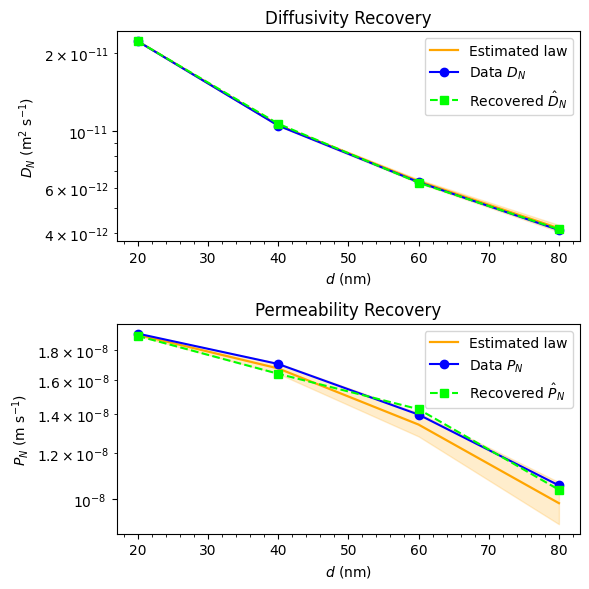

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))
plot_diffusivity(d_vals, D_vals, D_est_list, law_result["a_D_mean"], law_result["a_D_std"], phys, fig=fig, ax=axes[0])
plot_permeability(d_vals, P_vals, P_est_list, law_result["a_P_mean"], law_result["a_P_std"], phys, fig=fig, ax=axes[1])
fig.tight_layout()